In [1]:
import requests, json
from pathlib import Path

BASE_URL = "http://www.cbr.ru/dataservice"
params = {
    "publicationId": 33,
    "datasetId": 127,
    "y1": 2005,
    "y2": 2026,
}
response = requests.get(f"{BASE_URL}/data", params=params, timeout=30)
response.raise_for_status()
data = response.json()

# Сохраняем сырой JSON в raw/
RAW_JSON = Path("cbr_data.json")
with open(RAW_JSON, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)
print("JSON сохранён:", RAW_JSON, RAW_JSON.stat().st_size, "байт")

JSON сохранён: cbr_data.json 218493 байт


# Чистка

In [3]:
import pandas as pd
raws = data["RawData"]
df = pd.DataFrame(raws)
print(df.shape, list(df.columns))
display(df.head())

(783, 10) ['colId', 'element_id', 'measure_id', 'unit_id', 'obs_val', 'rowId', 'dt', 'periodicity', 'date', 'digits']


,colId,element_id,measure_id,unit_id,obs_val,rowId,dt,periodicity,date,digits
0,100,100,None,10,NaN,157,Январь 2005,month,2005-02-01T00:00:00,4
1,98,98,None,10,28.08,157,Январь 2005,month,2005-02-01T00:00:00,4
2,99,99,None,10,36.63,157,Январь 2005,month,2005-02-01T00:00:00,4
3,99,99,None,10,36.63,158,Февраль 2005,month,2005-03-01T00:00:00,4
4,100,100,None,10,NaN,158,Февраль 2005,month,2005-03-01T00:00:00,4


In [4]:
print("Пропуски:", df.isna().sum()[df.isna().sum() > 0])
print("Дубликаты:", df.duplicated().sum())
print("Типы:", df.dtypes)

Пропуски: measure_id    783
obs_val       216
dtype: int64
Дубликаты: 0
Типы: colId            int64
element_id       int64
measure_id      object
unit_id          int64
obs_val        float64
rowId            int64
dt              object
periodicity     object
date            object
digits           int64
dtype: object


In [5]:
df = df.dropna(subset=["obs_val"])
df = df.drop_duplicates(subset=["element_id", "dt"])
print("После чистки:", df.shape)

После чистки: (567, 10)


In [6]:
months = {
    "январь": "January", "февраль": "February", "март": "March",
    "апрель": "April", "май": "May", "июнь": "June",
    "июль": "July", "август": "August", "сентябрь": "September",
    "октябрь": "October", "ноябрь": "November", "декабрь": "December",
}
s = df["dt"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
for ru, en in months.items():
    s = s.str.replace(ru, en, case=False, regex=False)
df["dt_parsed"] = pd.to_datetime(s, format="%B %Y", errors="coerce")
df["dt_parsed"] = df["dt_parsed"] + pd.offsets.MonthEnd(0)
print(df[["dt", "dt_parsed"]].head())

             dt  dt_parsed
1   Январь 2005 2005-01-31
2   Январь 2005 2005-01-31
3  Февраль 2005 2005-02-28
5  Февраль 2005 2005-02-28
7     Март 2005 2005-03-31


In [7]:
df = df[["element_id", "unit_id", "dt_parsed", "obs_val"]].reset_index(drop=True)
print(df.dtypes)

element_id             int64
unit_id                int64
dt_parsed     datetime64[ns]
obs_val              float64
dtype: object


In [8]:
headers = pd.DataFrame(data["headerData"])
print(headers)  # смотрим id -> elname

    id                                elname
0   98  Доллара США к рублю на конец периода
1   99         Евро к рублю на конец периода
2  100         Юаня к рублю на конец периода


# Загрузка в Minio

In [9]:
import boto3
s3 = boto3.client("s3", endpoint_url="http://localhost:9000",
                  aws_access_key_id="admin", aws_secret_access_key="Admin12345")
BUCKET = "cbr-data"
try:
    s3.create_bucket(Bucket=BUCKET)
    print("Bucket создан")
except s3.exceptions.BucketAlreadyOwnedByYou:
    print("Bucket уже есть")

Bucket создан


In [10]:
df.to_parquet("cbr.parquet", index=False)

In [11]:
s3.upload_file("cbr_data.json", BUCKET, "raw/cbr_data.json")
s3.upload_file("cbr.parquet", BUCKET, "processed/cbr.parquet")

# Чтение паркета из минио

In [12]:
storage_options = {
    "key": "admin", "secret": "Admin12345",
    "client_kwargs": {"endpoint_url": "http://localhost:9000"}
}
df = pd.read_parquet(f"s3://{BUCKET}/processed/cbr.parquet",
                     storage_options=storage_options)

c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\fsspec\registry.py:298: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


# Макс мин по каждой валюте

In [13]:
stats = df.groupby("element_id")["obs_val"].agg(["min", "max"])
print(stats)

                min       max
element_id                   
98          23.4500  107.7409
99          33.3300  114.3149
100         10.3077   14.7233


In [14]:
best = df.loc[df.groupby("element_id")["obs_val"].idxmax(),
              ["element_id", "dt_parsed", "obs_val"]]
print(best)

     element_id  dt_parsed   obs_val
500          98 2024-11-30  107.7409
499          99 2024-11-30  114.3149
498         100 2024-11-30   14.7233


# Аналитика в минио

In [15]:
stats.reset_index().to_parquet("cbr_statistics.parquet", index=False)
s3.upload_file("cbr_statistics.parquet", BUCKET, "analytics/cbr_statistics.parquet")

# Графики на матплотлиб

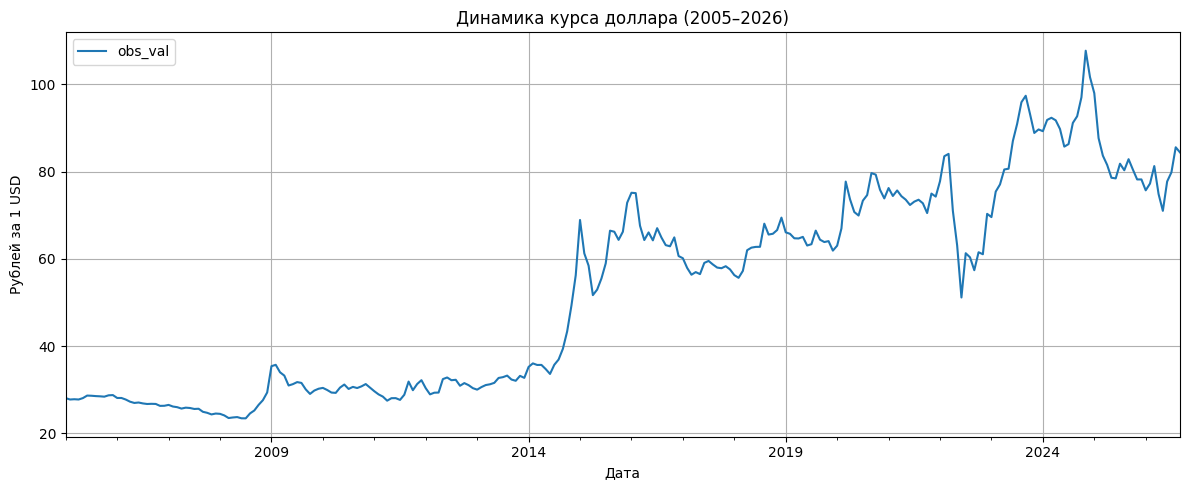

In [16]:
import matplotlib.pyplot as plt

df_usd = df[df["element_id"] == 98].sort_values("dt_parsed")
df_usd.plot(x="dt_parsed", y="obs_val", figsize=(12, 5),
            title="Динамика курса доллара (2005–2026)")
plt.xlabel("Дата"); plt.ylabel("Рублей за 1 USD"); plt.grid()
plt.tight_layout(); plt.show()